In [1]:
import torch

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedShuffleSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix as sklearn_confusion_matrix
from sklearn.metrics import accuracy_score, confusion_matrix

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import os

import time

import joblib

from tqdm.auto import tqdm

import tempfile

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
if torch.cuda.is_available():
  device = torch.device("cuda")
elif torch.backends.mps.is_available():
  device = torch.device("mps")
else:
  device = torch.device("cpu")
print(f"Device: {device}")

Device: cpu


In [3]:
seed = 2022
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)

max_workers = 0
batch_size = 32

# Process Dataset

In [ ]:
def cov_matrix_vectorized(x):
    """
    Convert one multivariate time-series sample into a vectorized covariance matrix.

    Input:
        x shape: (timesteps, features)

    Output:
        1D covariance feature vector
    """
    cov = np.cov(x, rowvar=False)

    # Use upper triangle, including diagonal, to avoid duplicate covariance entries
    idx = np.triu_indices_from(cov)

    return cov[idx]

In [ ]:
def split_data_combined_dataset(npz_path):

  # Read the npz file
  ml_data = np.load(npz_path)
  X, y, model = ml_data["X"], ml_data["y"], ml_data["model"]

  print(X.shape, y.shape, model.shape)

  # Get class names
  class_map = (
      pd.DataFrame({"y": y, "model": model})
      .drop_duplicates()
      .sort_values(by="y")
  )

  assert class_map["y"].is_unique
  assert class_map["model"].is_unique
  assert np.array_equal(class_map["y"].values, np.arange(len(class_map)))

  class_names = class_map["model"].values

  # Split the data into training, validation, and test dataset
  sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=37)
  for train_val_index, test_index in sss1.split(X, y):
    X_train_val, y_train_val = X[train_val_index], y[train_val_index]
    X_test, y_test = X[test_index], y[test_index]

  sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=38)
  for train_index, val_index in sss2.split(X_train_val, y_train_val):
    X_train, y_train = X_train_val[train_index], y_train_val[train_index]
    X_val, y_val = X_train_val[val_index], y_train_val[val_index]

  print(f"Train Shape: {X_train.shape}, {y_train.shape}")
  print(f"Val Shape: {X_val.shape}, {y_val.shape}")
  print(f"Test Shape: {X_test.shape}, {y_test.shape}")

  # Standardize the data on the training dataset only
  scaler = StandardScaler()

  # standardize first
  X_train = scaler.fit_transform(X_train.reshape(-1, X_train.shape[-1])).reshape(X_train.shape)
  X_val = scaler.transform(X_val.reshape(-1, X_val.shape[-1])).reshape(X_val.shape)
  X_test = scaler.transform(X_test.reshape(-1, X_test.shape[-1])).reshape(X_test.shape)

  # then convert each sample to covariance features
  X_train = np.array([cov_matrix_vectorized(x) for x in X_train])
  X_val = np.array([cov_matrix_vectorized(x) for x in X_val])
  X_test = np.array([cov_matrix_vectorized(x) for x in X_test])

  return X_train, y_train, X_val, y_val, X_test, y_test, class_names

In [ ]:
data_directory_path_combined = "/content/drive/MyDrive/MSEE/Spring 2026/EE513: Neural Networks/Final Project/Data/COMBINED"
data_directory_path_separate = "/content/drive/MyDrive/MSEE/Spring 2026/EE513: Neural Networks/Final Project/Data/SEPARATE"

combined_datasets = []
separate_datasets = []

for _file in os.listdir(data_directory_path_combined):
  if _file.endswith(".npz"):
    print(_file)
    combined_npz_path = os.path.join(data_directory_path_combined, _file)
    X_train, y_train, X_val, y_val, X_test, y_test, class_names = split_data_combined_dataset(combined_npz_path)
    combined_datasets.append({
        "name": _file,
        "X_train": X_train,
        "y_train": y_train,
        "X_val": X_val,
        "y_val": y_val,
        "X_test": X_test,
        "y_test": y_test
        })


60-start-1-cpu-gpu.npz
(18238, 540, 15) (18238,) (18238,)
Train Shape: (11672, 540, 15), (11672,)
Val Shape: (2918, 540, 15), (2918,)
Test Shape: (3648, 540, 15), (3648,)
60-middle-1-cpu-gpu.npz
(17767, 540, 15) (17767,) (17767,)
Train Shape: (11370, 540, 15), (11370,)
Val Shape: (2843, 540, 15), (2843,)
Test Shape: (3554, 540, 15), (3554,)
60-random-1-cpu-gpu.npz
(17728, 540, 15) (17728,) (17728,)
Train Shape: (11345, 540, 15), (11345,)
Val Shape: (2837, 540, 15), (2837,)
Test Shape: (3546, 540, 15), (3546,)
60-random-2-cpu-gpu.npz
(17725, 540, 15) (17725,) (17725,)
Train Shape: (11344, 540, 15), (11344,)
Val Shape: (2836, 540, 15), (2836,)
Test Shape: (3545, 540, 15), (3545,)
60-random-3-cpu-gpu.npz
(17741, 540, 15) (17741,) (17741,)
Train Shape: (11353, 540, 15), (11353,)
Val Shape: (2839, 540, 15), (2839,)
Test Shape: (3549, 540, 15), (3549,)
60-random-4-cpu-gpu.npz
(17724, 540, 15) (17724,) (17724,)
Train Shape: (11343, 540, 15), (11343,)
Val Shape: (2836, 540, 15), (2836,)
Test S

# Models

## Random Forest

In [4]:
def build_rf():
  return RandomForestClassifier(
      random_state=42,
      bootstrap=False,
      n_jobs=-1
  )

random_forest_parameters = {
    "n_estimators": [50, 100, 250],
    "max_depth": [None, 10, 20],
    "min_samples_leaf": [1, 2, 5],
    }

In [6]:
build_rf

<function __main__.build_rf()>

## Support Vector Machine

In [5]:
def build_svm():
  return SVC(decision_function_shape="ovo")

svm_parameters = {"kernel": ["linear", "poly"], "C": [0.1, 1, 10]}

# Training and Evaluation Function

In [ ]:
def ensure_2d(X_train, X_val, X_test):
    return (
        X_train.reshape(X_train.shape[0], -1),
        X_val.reshape(X_val.shape[0], -1),
        X_test.reshape(X_test.shape[0], -1),
    )

In [ ]:
def get_sklearn_model_size_bytes(model):
    """
    Approximate saved model size by temporarily dumping it with joblib.
    """
    with tempfile.NamedTemporaryFile(suffix=".joblib", delete=False) as tmp:
        tmp_path = tmp.name

    try:
        joblib.dump(model, tmp_path)
        size_bytes = os.path.getsize(tmp_path)
    finally:
        if os.path.exists(tmp_path):
            os.remove(tmp_path)

    return size_bytes


def get_sklearn_model_complexity(model):
    """
    Returns model-specific complexity metrics for sklearn models.

    Note:
    sklearn models do not have 'trainable parameters' in the same way
    neural networks do, so these are proxy metrics.
    """
    complexity = {
        "total_params": None,
        "trainable_params": None,
        "model_size_bytes": None,
        "num_estimators": None,
        "rf_total_nodes": None,
        "rf_total_leaves": None,
        "rf_avg_depth": None,
        "svm_num_support_vectors": None,
        "svm_num_coefficients": None,
    }

    # Approximate storage size
    complexity["model_size_bytes"] = get_sklearn_model_size_bytes(model)

    # Random Forest
    if hasattr(model, "estimators_"):
        trees = model.estimators_

        total_nodes = sum(tree.tree_.node_count for tree in trees)
        total_leaves = sum(
            np.sum(tree.tree_.children_left == -1)
            for tree in trees
        )
        avg_depth = np.mean([tree.tree_.max_depth for tree in trees])

        complexity["num_estimators"] = len(trees)
        complexity["rf_total_nodes"] = int(total_nodes)
        complexity["rf_total_leaves"] = int(total_leaves)
        complexity["rf_avg_depth"] = float(avg_depth)

        # For RF, a reasonable proxy for learned parameters is tree nodes.
        complexity["total_params"] = int(total_nodes)
        complexity["trainable_params"] = int(total_nodes)

    # Kernel SVC
    if hasattr(model, "support_vectors_"):
        complexity["svm_num_support_vectors"] = int(model.support_vectors_.shape[0])

        # Dual coefficients shape is usually [n_classes - 1, n_support_vectors]
        if hasattr(model, "dual_coef_"):
            complexity["svm_num_coefficients"] = int(model.dual_coef_.size)
            complexity["total_params"] = int(model.dual_coef_.size)
            complexity["trainable_params"] = int(model.dual_coef_.size)

    # LinearSVC / linear models
    if hasattr(model, "coef_"):
        num_coef = int(model.coef_.size)

        if hasattr(model, "intercept_"):
            num_coef += int(model.intercept_.size)

        complexity["svm_num_coefficients"] = num_coef
        complexity["total_params"] = num_coef
        complexity["trainable_params"] = num_coef

    return complexity

In [ ]:
def main(
    dataset_ls,
    model_builder,
    model_parameters,
    model_name,
    separate=False,
    save_model=True,
):
    results = []

    MODEL_SAVE_DIR = "/content/drive/MyDrive/MSEE/Spring 2026/EE513: Neural Networks/Final Project/Models"
    os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

    for dataset in tqdm(dataset_ls):
        dataset_name = dataset["name"]
        X_train = dataset["X_train"]
        y_train = dataset["y_train"]
        X_val = dataset["X_val"]
        y_val = dataset["y_val"]
        X_test = dataset["X_test"]
        y_test = dataset["y_test"]

        X_train_2d, X_val_2d, X_test_2d = ensure_2d(
            X_train,
            X_val,
            X_test,
        )

        tqdm.write(f"Training {model_name} on {dataset_name}")

        model = model_builder()

        clf = GridSearchCV(
            estimator=model,
            param_grid=model_parameters,
            scoring="accuracy",
            n_jobs=-1,
            cv=5,
            verbose=1,
        )

        # Measure full grid-search training duration
        start_time = time.perf_counter()

        clf.fit(X_train_2d, y_train)

        end_time = time.perf_counter()

        training_duration_sec = end_time - start_time
        training_duration_min = training_duration_sec / 60

        best_model = clf.best_estimator_

        # Model complexity / parameter proxies
        complexity = get_sklearn_model_complexity(best_model)

        save_path = None

        if save_model:
            clean_dataset_name = dataset_name.replace(".npz", "")
            save_path = os.path.join(
                MODEL_SAVE_DIR,
                f"{model_name}_{clean_dataset_name}.joblib"
            )
            joblib.dump(best_model, save_path)
            tqdm.write(f"Saved model to: {save_path}")

        train_preds = best_model.predict(X_train_2d)
        val_preds = best_model.predict(X_val_2d)
        test_preds = best_model.predict(X_test_2d)

        train_acc = accuracy_score(y_train, train_preds)
        val_acc = accuracy_score(y_val, val_preds)
        test_acc = accuracy_score(y_test, test_preds)

        tqdm.write(f"{model_name} on {dataset_name}")
        tqdm.write(f"Best params: {clf.best_params_}")
        tqdm.write(f"CV best score: {clf.best_score_:.4f}")
        tqdm.write(f"Train acc: {train_acc:.4f}")
        tqdm.write(f"Val acc: {val_acc:.4f}")
        tqdm.write(f"Test acc: {test_acc:.4f}")
        tqdm.write(f"Training duration: {training_duration_min:.2f} min")

        if complexity["total_params"] is not None:
            tqdm.write(f"Total parameter proxy: {complexity['total_params']:,}")

        if complexity["model_size_bytes"] is not None:
            tqdm.write(
                f"Model size: {complexity['model_size_bytes'] / 1024**2:.2f} MB"
            )

        results.append({
            "model_name": model_name,
            "dataset_name": dataset_name,

            # Hyperparameter search
            "best_params": clf.best_params_,
            "cv_best_score": clf.best_score_,
            "cv_results": clf.cv_results_,

            # Performance
            "train_acc": train_acc,
            "val_acc": val_acc,
            "test_acc": test_acc,
            "test_labels": y_test,
            "test_preds": test_preds,

            # Timing
            "training_duration_sec": training_duration_sec,
            "training_duration_min": training_duration_min,

            # sklearn complexity proxies
            "total_params": complexity["total_params"],
            "trainable_params": complexity["trainable_params"],
            "model_size_bytes": complexity["model_size_bytes"],
            "model_size_mb": (
                complexity["model_size_bytes"] / 1024**2
                if complexity["model_size_bytes"] is not None
                else None
            ),

            # RF-specific
            "num_estimators": complexity["num_estimators"],
            "rf_total_nodes": complexity["rf_total_nodes"],
            "rf_total_leaves": complexity["rf_total_leaves"],
            "rf_avg_depth": complexity["rf_avg_depth"],

            # SVM-specific
            "svm_num_support_vectors": complexity["svm_num_support_vectors"],
            "svm_num_coefficients": complexity["svm_num_coefficients"],

            # Saved model
            "model_path": save_path,
        })

    return results

In [ ]:
def baseline_results_to_dataframe(results):
    rows = []

    for r in results:
        rows.append({
            "model_name": r["model_name"],
            "dataset_name": r["dataset_name"],
            "cv_best_score": r["cv_best_score"],
            "train_acc": r["train_acc"],
            "val_acc": r["val_acc"],
            "test_acc": r["test_acc"],
            "best_params": r["best_params"],
            "training_duration_min": r["training_duration_min"],
            "model_size_mb": r["model_size_mb"],
            "total_params": r["total_params"],
            "trainable_params": r["trainable_params"],
            "num_estimators": r["num_estimators"],
            "rf_total_nodes": r["rf_total_nodes"],
            "rf_total_leaves": r["rf_total_leaves"],
            "rf_avg_depth": r["rf_avg_depth"],
            "svm_num_support_vectors": r["svm_num_support_vectors"],
            "svm_num_coefficients": r["svm_num_coefficients"],
            "model_path": r["model_path"],
        })

    return pd.DataFrame(rows).sort_values("test_acc", ascending=False)

In [ ]:
def get_best_and_worst_results(results, metric="test_acc"):
    """
    Returns the best and worst result dictionaries based on a metric.

    For accuracy, higher is better.
    For loss, lower is better.
    """

    if len(results) == 0:
        raise ValueError("results list is empty.")

    if metric in ["test_acc", "val_acc", "accuracy"]:
        best_result = max(results, key=lambda r: r[metric])
        worst_result = min(results, key=lambda r: r[metric])

    elif metric in ["test_loss", "val_loss", "loss"]:
        best_result = min(results, key=lambda r: r[metric])
        worst_result = max(results, key=lambda r: r[metric])

    else:
        raise ValueError(f"Unknown metric: {metric}")

    return best_result, worst_result

# Visualize Data

In [ ]:
def plot_training_curves_from_result(result):
    """
    Plot train/validation loss and accuracy curves for one result dictionary.
    """

    model_name = result["model_name"]
    dataset_name = result["dataset_name"]

    train_losses = result["train_losses"]
    val_losses = result["val_losses"]
    train_accs = result["train_accs"]
    val_accs = result["val_accs"]

    epochs = np.arange(1, len(train_losses) + 1)

    plt.figure(figsize=(12, 5))

    # Loss plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, label="Train loss")
    plt.plot(epochs, val_losses, label="Validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss")
    plt.legend()
    plt.grid(True)

    # Accuracy plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_accs, label="Train accuracy")
    plt.plot(epochs, val_accs, label="Validation accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Accuracy")
    plt.legend()
    plt.grid(True)

    plt.suptitle(
        f"{model_name} on {dataset_name}\n"
        f"Test accuracy: {result['test_acc']:.4f}, Test loss: {result['test_loss']:.4f}"
    )

    plt.tight_layout()
    plt.show()

In [ ]:
def plot_confusion_matrix_from_result(
    result,
    class_names=None,
    normalize=False,
    figsize=(12, 10),
):
    """
    Plot confusion matrix for one result dictionary.

    If normalize=True, rows are normalized by true class count.
    """

    model_name = result["model_name"]
    dataset_name = result["dataset_name"]

    y_true = result["test_labels"]
    y_pred = result["test_preds"]

    cm = sklearn_confusion_matrix(y_true, y_pred)

    if normalize:
        cm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
        fmt = ".2f"
        title_extra = "Normalized confusion matrix"
    else:
        fmt = "d"
        title_extra = "Confusion matrix"

    plt.figure(figsize=figsize)

    sns.heatmap(
        cm,
        annot=False,
        fmt=fmt,
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
    )

    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.title(
        f"{title_extra}\n{model_name} on {dataset_name}\n"
        f"Test accuracy: {result['test_acc']:.4f}"
    )

    plt.tight_layout()
    plt.show()

In [ ]:
def plot_best_and_worst_baseline_runs(
    results,
    metric="test_acc",
    class_names=None,
    normalize_cm=False,
):
    best_result, worst_result = get_best_and_worst_results(results, metric=metric)

    print("Best run:")
    print("Model:", best_result["model_name"])
    print("Dataset:", best_result["dataset_name"])
    print("CV best score:", best_result["cv_best_score"])
    print("Train accuracy:", best_result["train_acc"])
    print("Val accuracy:", best_result["val_acc"])
    print("Test accuracy:", best_result["test_acc"])
    print("Best params:", best_result["best_params"])
    print()

    plot_confusion_matrix_from_result(
        best_result,
        class_names=class_names,
        normalize=normalize_cm,
    )

    print("Worst run:")
    print("Model:", worst_result["model_name"])
    print("Dataset:", worst_result["dataset_name"])
    print("CV best score:", worst_result["cv_best_score"])
    print("Train accuracy:", worst_result["train_acc"])
    print("Val accuracy:", worst_result["val_acc"])
    print("Test accuracy:", worst_result["test_acc"])
    print("Best params:", worst_result["best_params"])
    print()

    plot_confusion_matrix_from_result(
        worst_result,
        class_names=class_names,
        normalize=normalize_cm,
    )

    return best_result, worst_result

# Random Forest

In [ ]:
results_rf = main(
    dataset_ls=combined_datasets,
    model_builder=build_rf,
    model_parameters=random_forest_parameters,
    model_name="Random_Forest",
    separate=False,
    save_model=True,
)

  0%|          | 0/7 [00:00<?, ?it/s]

Training Random_Forest on 60-start-1-cpu-gpu.npz
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Saved model to: /content/drive/MyDrive/MSEE/Spring 2026/EE513: Neural Networks/Final Project/Models/Random_Forest_60-start-1-cpu-gpu.joblib
Random_Forest on 60-start-1-cpu-gpu.npz
Best params: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 250}
CV best score: 0.9224
Train acc: 1.0000
Val acc: 0.9345
Test acc: 0.9383
Training duration: 9.37 min
Total parameter proxy: 535,540
Model size: 139.06 MB
Training Random_Forest on 60-middle-1-cpu-gpu.npz
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Saved model to: /content/drive/MyDrive/MSEE/Spring 2026/EE513: Neural Networks/Final Project/Models/Random_Forest_60-middle-1-cpu-gpu.joblib
Random_Forest on 60-middle-1-cpu-gpu.npz
Best params: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 250}
CV best score: 0.9580
Train acc: 1.0000
Val acc: 0.9726
Test acc: 0.9657
Training duration: 9.84 min
Total 

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Saved model to: /content/drive/MyDrive/MSEE/Spring 2026/EE513: Neural Networks/Final Project/Models/Random_Forest_60-random-1-cpu-gpu.joblib
Random_Forest on 60-random-1-cpu-gpu.npz
Best params: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 250}
CV best score: 0.9309
Train acc: 1.0000
Val acc: 0.9492
Test acc: 0.9535
Training duration: 10.71 min
Total parameter proxy: 755,302
Model size: 196.06 MB
Training Random_Forest on 60-random-2-cpu-gpu.npz
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Saved model to: /content/drive/MyDrive/MSEE/Spring 2026/EE513: Neural Networks/Final Project/Models/Random_Forest_60-random-2-cpu-gpu.joblib
Random_Forest on 60-random-2-cpu-gpu.npz
Best params: {'max_depth': 20, 'min_samples_leaf': 1, 'n_estimators': 250}
CV best score: 0.9267
Train acc: 1.0000
Val acc: 0.9461
Test acc: 0.9391
Training duration: 10.85 min
Total parameter proxy: 691,652
Model size: 179.56 MB
Training Random_Forest on 60-random-3-cpu-gpu.npz
Fitting 5 fo

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Saved model to: /content/drive/MyDrive/MSEE/Spring 2026/EE513: Neural Networks/Final Project/Models/Random_Forest_60-random-5-cpu-gpu.joblib
Random_Forest on 60-random-5-cpu-gpu.npz
Best params: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 250}
CV best score: 0.9311
Train acc: 1.0000
Val acc: 0.9454
Test acc: 0.9445
Training duration: 10.24 min
Total parameter proxy: 761,548
Model size: 197.68 MB


Best run:
Model: Random_Forest
Dataset: 60-middle-1-cpu-gpu.npz
CV best score: 0.9580474934036939
Train accuracy: 1.0
Val accuracy: 0.972564192754133
Test accuracy: 0.9656724817107485
Best params: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 250}



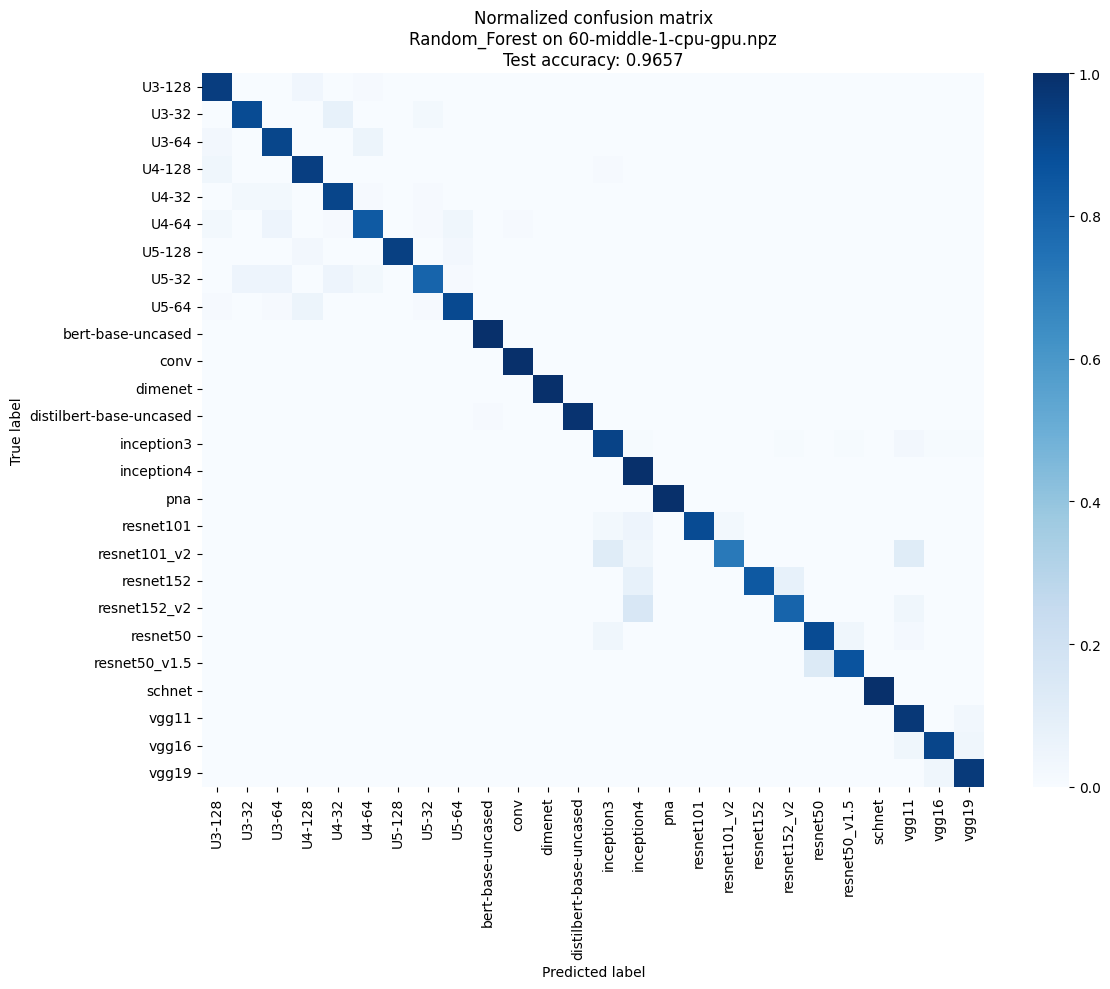

Worst run:
Model: Random_Forest
Dataset: 60-start-1-cpu-gpu.npz
CV best score: 0.922378323232212
Train accuracy: 1.0
Val accuracy: 0.9345442083618917
Test accuracy: 0.9383223684210527
Best params: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 250}



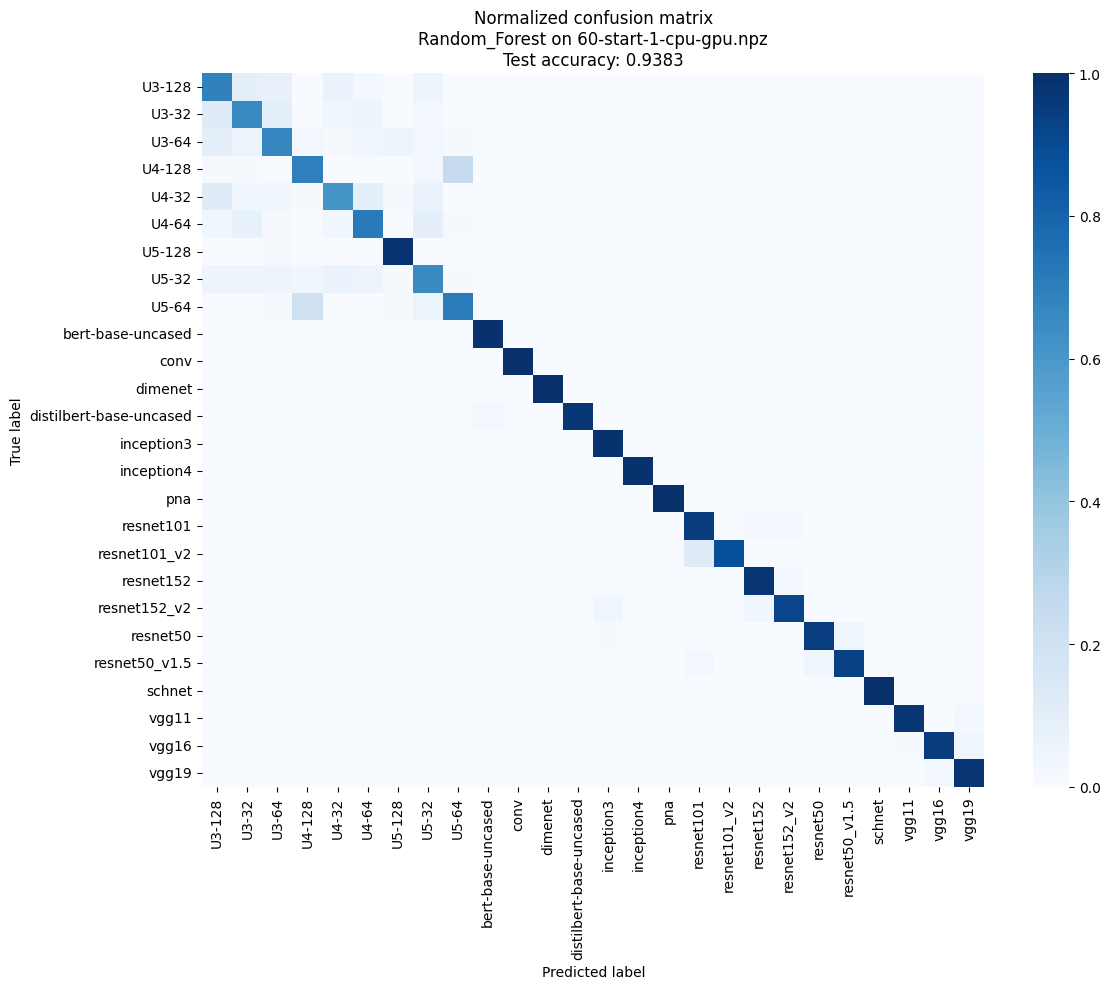

In [ ]:
best_result, worst_result = plot_best_and_worst_baseline_runs(
    results_rf,
    metric="test_acc",
    class_names=class_names,
    normalize_cm=True,
)

# Support Vector Machines

In [ ]:
results_svm = main(
    dataset_ls=combined_datasets,
    model_builder=build_svm,
    model_parameters=svm_parameters,
    model_name="Suppose_Vector_Machine",
    separate=False,
    save_model=True,
)

  0%|          | 0/7 [00:00<?, ?it/s]

Training Suppose_Vector_Machine on 60-start-1-cpu-gpu.npz
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Saved model to: /content/drive/MyDrive/MSEE/Spring 2026/EE513: Neural Networks/Final Project/Models/Suppose_Vector_Machine_60-start-1-cpu-gpu.joblib
Suppose_Vector_Machine on 60-start-1-cpu-gpu.npz
Best params: {'C': 10, 'kernel': 'linear'}
CV best score: 0.8197
Train acc: 0.8398
Val acc: 0.8170
Test acc: 0.8202
Training duration: 2.50 min
Total parameter proxy: 39,325
Model size: 4.75 MB
Training Suppose_Vector_Machine on 60-middle-1-cpu-gpu.npz
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Saved model to: /content/drive/MyDrive/MSEE/Spring 2026/EE513: Neural Networks/Final Project/Models/Suppose_Vector_Machine_60-middle-1-cpu-gpu.joblib
Suppose_Vector_Machine on 60-middle-1-cpu-gpu.npz
Best params: {'C': 10, 'kernel': 'linear'}
CV best score: 0.7372
Train acc: 0.7555
Val acc: 0.7478
Test acc: 0.7420
Training duration: 0.98 min
Total parameter proxy: 39,3

Best run:
Model: Suppose_Vector_Machine
Dataset: 60-start-1-cpu-gpu.npz
CV best score: 0.8197394075843732
Train accuracy: 0.839787525702536
Val accuracy: 0.8169979437971213
Test accuracy: 0.8201754385964912
Best params: {'C': 10, 'kernel': 'linear'}



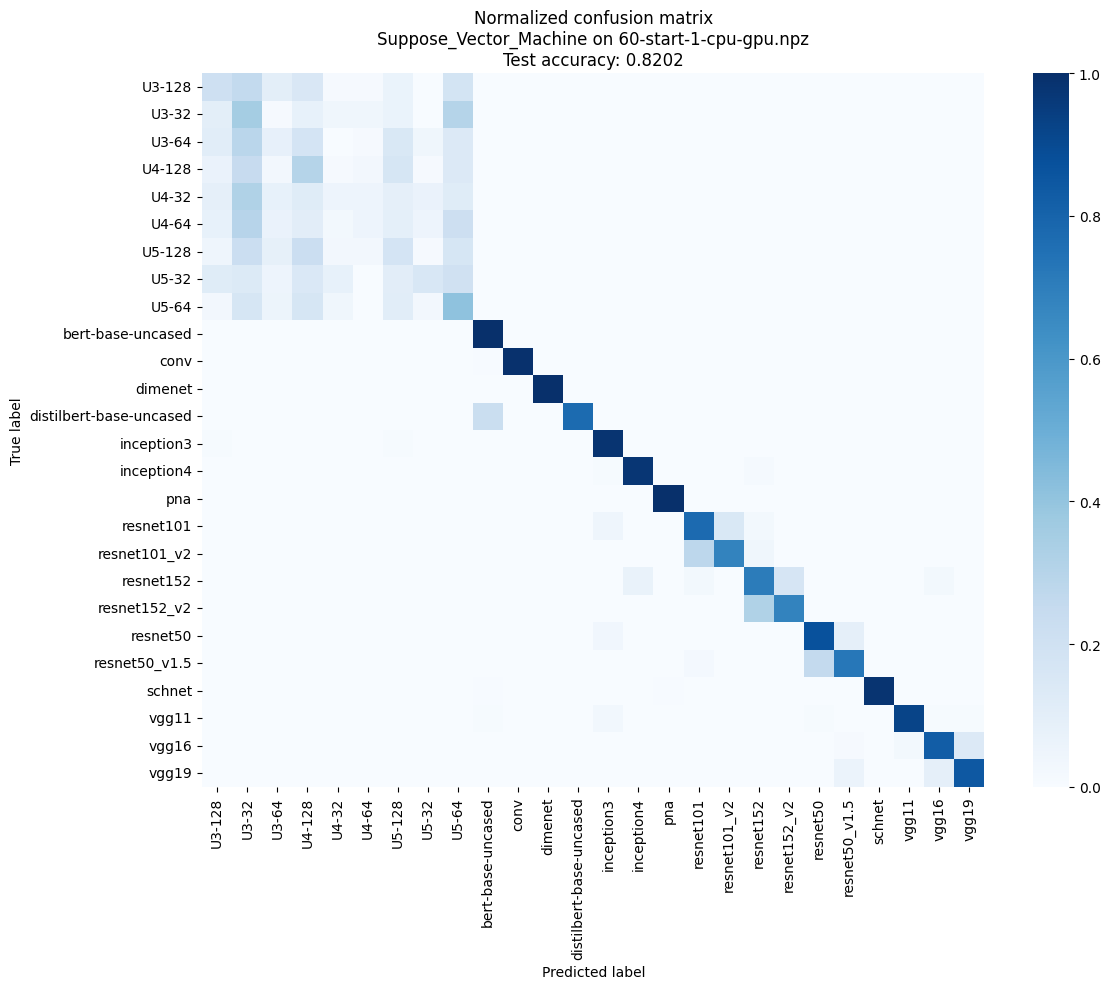

Worst run:
Model: Suppose_Vector_Machine
Dataset: 60-random-3-cpu-gpu.npz
CV best score: 0.7139965898311791
Train accuracy: 0.7335506033647494
Val accuracy: 0.7227897146882705
Test accuracy: 0.715694561848408
Best params: {'C': 10, 'kernel': 'linear'}



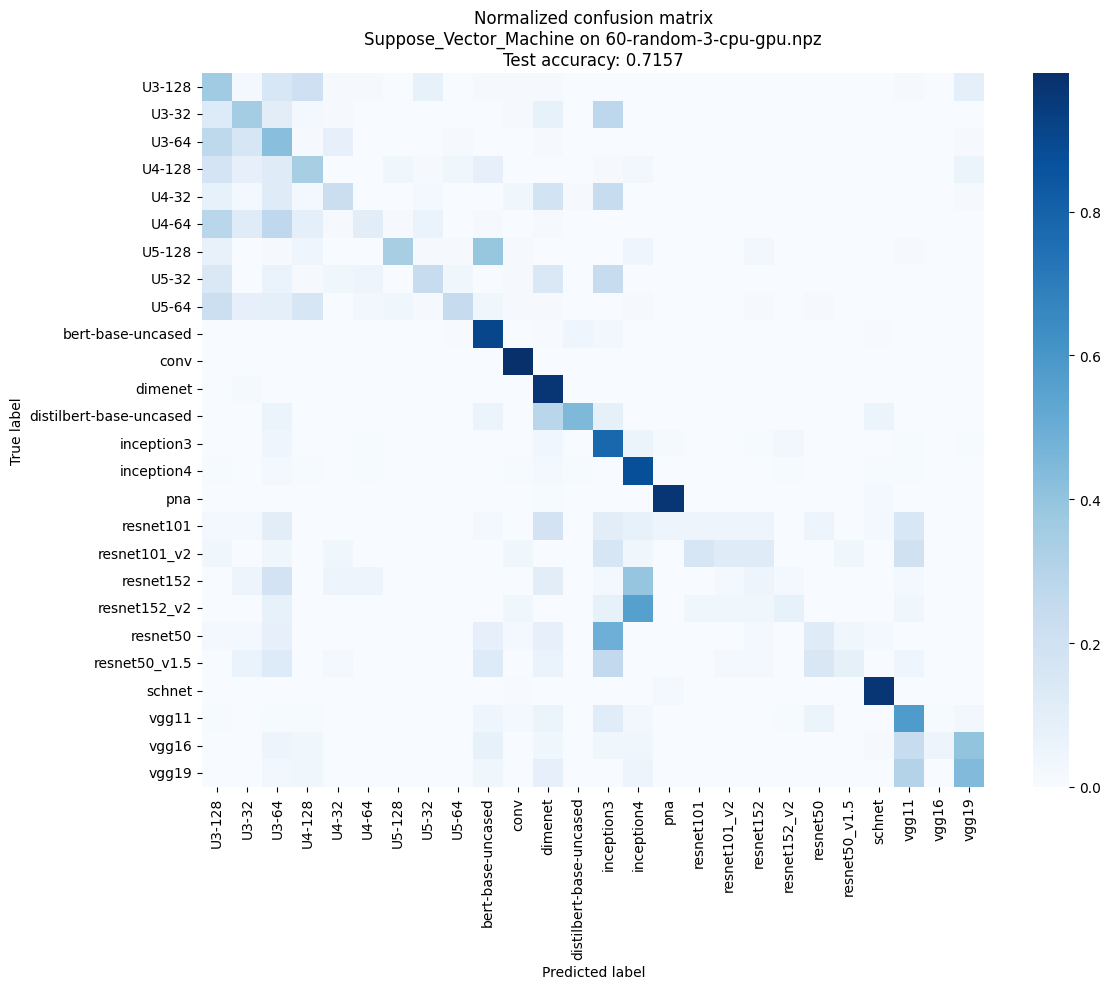

In [ ]:
best_result, worst_result = plot_best_and_worst_baseline_runs(
    results_svm,
    metric="test_acc",
    class_names=class_names,
    normalize_cm=True,
)

In [ ]:
all_results = results_rf + results_svm

In [ ]:
summary_df = baseline_results_to_dataframe(all_results)
summary_df

,model_name,dataset_name,cv_best_score,train_acc,val_acc,test_acc,best_params,training_duration_min,model_size_mb,total_params,trainable_params,num_estimators,rf_total_nodes,rf_total_leaves,rf_avg_depth,svm_num_support_vectors,svm_num_coefficients,model_path
1,Random_Forest,60-middle-1-cpu-gpu.npz,0.958047,1.000000,0.972564,0.965672,"{'max_depth': None, 'min_samples_leaf': 1, 'n_...",9.840891,155.645226,599486,599486,250.0,599486.0,299868.0,30.580,NaN,NaN,/content/drive/MyDrive/MSEE/Spring 2026/EE513:...
2,Random_Forest,60-random-1-cpu-gpu.npz,0.930895,1.000000,0.949242,0.953469,"{'max_depth': None, 'min_samples_leaf': 1, 'n_...",10.707824,196.063806,755302,755302,250.0,755302.0,377776.0,29.352,NaN,NaN,/content/drive/MyDrive/MSEE/Spring 2026/EE513:...
5,Random_Forest,60-random-4-cpu-gpu.npz,0.938023,1.000000,0.946051,0.947532,"{'max_depth': None, 'min_samples_leaf': 1, 'n_...",10.349465,195.699609,753898,753898,250.0,753898.0,377074.0,29.436,NaN,NaN,/content/drive/MyDrive/MSEE/Spring 2026/EE513:...
4,Random_Forest,60-random-3-cpu-gpu.npz,0.935259,1.000000,0.950687,0.945900,"{'max_depth': None, 'min_samples_leaf': 1, 'n_...",10.490620,198.726800,765568,765568,250.0,765568.0,382909.0,29.148,NaN,NaN,/content/drive/MyDrive/MSEE/Spring 2026/EE513:...
6,Random_Forest,60-random-5-cpu-gpu.npz,0.931090,1.000000,0.945384,0.944460,"{'max_depth': None, 'min_samples_leaf': 1, 'n_...",10.241477,197.684014,761548,761548,250.0,761548.0,380899.0,28.676,NaN,NaN,/content/drive/MyDrive/MSEE/Spring 2026/EE513:...
3,Random_Forest,60-random-2-cpu-gpu.npz,0.926745,1.000000,0.946051,0.939069,"{'max_depth': 20, 'min_samples_leaf': 1, 'n_es...",10.850065,179.556832,691652,691652,250.0,691652.0,345951.0,20.000,NaN,NaN,/content/drive/MyDrive/MSEE/Spring 2026/EE513:...
0,Random_Forest,60-start-1-cpu-gpu.npz,0.922378,1.000000,0.934544,0.938322,"{'max_depth': None, 'min_samples_leaf': 1, 'n_...",9.368661,139.057672,535540,535540,250.0,535540.0,267895.0,29.912,NaN,NaN,/content/drive/MyDrive/MSEE/Spring 2026/EE513:...
7,Suppose_Vector_Machine,60-start-1-cpu-gpu.npz,0.819739,0.839788,0.816998,0.820175,"{'C': 10, 'kernel': 'linear'}",2.500272,4.745708,39325,39325,NaN,NaN,NaN,NaN,3641.0,39325.0,/content/drive/MyDrive/MSEE/Spring 2026/EE513:...
8,Suppose_Vector_Machine,60-middle-1-cpu-gpu.npz,0.737203,0.755497,0.747802,0.741981,"{'C': 10, 'kernel': 'linear'}",0.975190,7.580165,39325,39325,NaN,NaN,NaN,NaN,5820.0,39325.0,/content/drive/MyDrive/MSEE/Spring 2026/EE513:...
13,Suppose_Vector_Machine,60-random-5-cpu-gpu.npz,0.726031,0.744977,0.731853,0.734423,"{'C': 10, 'kernel': 'linear'}",1.072998,7.944392,39325,39325,NaN,NaN,NaN,NaN,6100.0,39325.0,/content/drive/MyDrive/MSEE/Spring 2026/EE513:...


In [ ]:
summary_df.groupby("model_name").mean("test_acc").sort_values("test_acc", ascending=False)

,cv_best_score,train_acc,val_acc,test_acc,training_duration_min,model_size_mb,total_params,trainable_params,num_estimators,rf_total_nodes,rf_total_leaves,rf_avg_depth,svm_num_support_vectors,svm_num_coefficients
model_name,,,,,,,,,,,,,,
Random_Forest,0.934634,1.000000,0.949218,0.947775,10.264143,180.347708,694713.428571,694713.428571,250.0,694713.428571,347481.714286,28.157714,NaN,NaN
Suppose_Vector_Machine,0.736470,0.756213,0.744631,0.741196,1.229026,7.456407,39325.000000,39325.000000,NaN,NaN,NaN,NaN,5724.857143,39325.0
